In [1]:
from pathlib import Path

import random
import numpy as np
import pandas as pd
from datasets import load_from_disk

from src.utils import set_seed, print_runtime, create_folder, get_folder_size, print_message, pprint
from src.data.registry import REGISTRY
from src.data.sampler import DatasetSampler
from src.data.loader import HuggingFaceDatasetLoader
from src.data.canonical import (
    CanonicalDatasetBuilder,
    CanonicalDatasetVisualizer,
    CanonicalDatasetSerializer,
)
from src.config import CONFIG

In [2]:
print(CONFIG)

{'seed': 42, 'data': {'datasets': ['textvqa', 'gqa', 'vqav2'], 'max_size': 1000}, 'model': {'models': ['llava-hf/llava-1.5-7b-hf'], 'active_model': 'llava-hf/llava-1.5-7b-hf', 'use_4bit': True}, 'mask_strategies': {'image': ['black_image'], 'text': ['neutral_prompt']}, 'directories': {'datasets': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/data/datasets'), 'models': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/model/models'), 'results': PosixPath('/Users/bubukasharif/Desktop/Thesis/src/outputs/results'), 'figures': PosixPath('/Users/bubukasharif/Desktop/Thesis/src/outputs/figures'), 'checkpoints': PosixPath('/Users/bubukasharif/Desktop/Thesis/src/outputs/checkpoints'), 'logs': PosixPath('/Users/bubukasharif/Desktop/Thesis/src/outputs/logs')}}


In [3]:
set_seed(CONFIG["seed"])

print_runtime()

PyTorch version: 2.12.1
CUDA available: False
No GPU detected.


In [4]:
datasets = {}
dataset_root = Path(CONFIG["directories"]["datasets"])

for dataset_key in CONFIG["data"]["datasets"]:
    dataset_config = REGISTRY[dataset_key]
    dataset_path = dataset_root / dataset_key
    loader = HuggingFaceDatasetLoader(REGISTRY, CONFIG)
    dataset = loader.load(dataset_key)
    sampler = DatasetSampler(CONFIG)
    sampled_dataset = sampler.sample(dataset)
    canonical_builder = CanonicalDatasetBuilder(dataset_key, dataset_config)
    canonical_data = canonical_builder.build_dataset(sampled_dataset)
    datasets[dataset_key] = sampler.sample(canonical_data)

Loaded dataset textvqa with 34602 samples
Created canonical dataset textvqa with 1000 samples
Loaded dataset gqa with 72140 samples
Created canonical dataset gqa with 1000 samples
Loaded dataset vqav2 with 214354 samples
Created canonical dataset vqav2 with 1000 samples


TASK textvqa | Sample INDEX 224
Dataset: textvqa
Task: textvqa
Sample ID: textvqa_314
Question: what company is on the side of this van?
Answer: south west water
All answers: ['south west water', 'south west water', 'south west water', 'southwest water', 'south west water', 'south west water', 'i was reading a cientific article', 'south west water', 'southwest water', 'south west water']
Metadata: {'raw_index': 314, 'image_id': '3b19567e2bd430c2'}


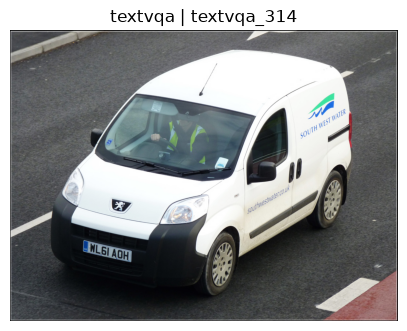

TASK gqa | Sample INDEX 701
Dataset: gqa
Task: gqa
Sample ID: gqa_425
Question: What is the device that is to the right of the dinosaur near the wall?
Answer: television
All answers: ['television']
Metadata: {'raw_index': 425, 'qa_index': 0, 'image_id': '425', 'full_answer': 'The device is a television.', 'num_available_qa_pairs': 28}


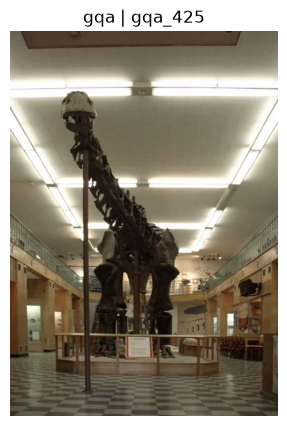

TASK vqav2 | Sample INDEX 332
Dataset: vqav2
Task: vqav2
Sample ID: vqav2_242
Question: Is this a train?
Answer: no
All answers: ['no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no']
Metadata: {'raw_index': 242, 'image_id': '115885'}


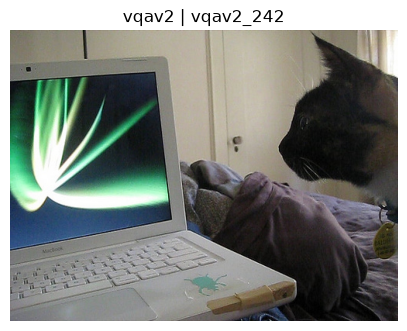

In [49]:
canonical_visualizer = CanonicalDatasetVisualizer(datasets)

canonical_visualizer.preview_sample("textvqa", random.randint(0, len(datasets["textvqa"]) - 1), show_image=True)

canonical_visualizer.preview_sample("gqa", random.randint(0, len(datasets["gqa"]) - 1), show_image=True)

canonical_visualizer.preview_sample("vqav2", random.randint(0, len(datasets["vqav2"]) - 1), show_image=True)